<a href="https://colab.research.google.com/github/SergeiVKalinin/MSE_Spring_2026/blob/main/Module%204/25_VanDerPol_PINN_ParameterDiscovery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Van der Pol Oscillator: Parameter Discovery with a PINN

**Course: MSE 510/420, Spring 2026**

This notebook solves a **parameter identification problem** using a Physics-Informed Neural Network (PINN) implemented entirely from scratch in NumPy — no TensorFlow or PyTorch required.

**The problem:** Given observations of a Van der Pol oscillator, recover the nonlinearity parameter $\mu$ from data and the known equation structure.

**The system:**
$$\dot{x} = y$$
$$\dot{y} = \mu(1 - x^2)y - x$$

**Known:** both equation structures. **Unknown:** $\mu$. **Ground truth:** $\mu = 2.0$. **Initial guess:** $\mu_0 = 0.5$.

---

### Why this is harder than it looks

A PINN identifies $\mu$ through the ODE residual:
$$r_y = \frac{d\hat{y}}{dt} - \mu(1 - \hat{x}^2)\hat{y} + \hat{x}$$

The gradient $\partial \mathcal{L}_\text{ODE}/\partial \mu = \langle 2r_y \cdot (-(1-\hat{x}^2)\hat{y}) \rangle$ is only informative when $d\hat{y}/dt$ is **accurate**. This derivative comes from differentiating the neural network output with respect to $t$ — which requires the network to have learned the trajectory well.

A plain `tanh` MLP with raw $t$ as input suffers from **spectral bias**: it preferentially learns low-frequency components and struggles with oscillatory solutions. With trajectory RMSE $\sim 0.5$, the computed $d\hat{y}/dt$ is wrong and the $\mu$ gradient becomes ambiguous.

**The fix: Fourier input encoding.** We encode $t$ as:
$$[t,\ \sin(\omega_1 t),\ \cos(\omega_1 t),\ \sin(\omega_2 t),\ \cos(\omega_2 t),\ \ldots]$$
using the fundamental frequency and harmonics. This places the oscillatory basis into the input space, overcoming spectral bias and reducing trajectory RMSE from $\sim 0.5$ to $< 0.05$.

### This notebook is implemented entirely in NumPy

We build the full PINN machinery by hand:
- Forward pass through a multilayer perceptron
- Analytical backpropagation (no finite differences)
- Forward-mode automatic differentiation for $d\hat{u}/dt$
- Adam optimiser with separate learning rates for network and $\mu$

### 0. Imports

No deep learning framework needed. `numpy` handles all linear algebra, `scipy.integrate.solve_ivp` generates the ground-truth data, and `matplotlib` handles visualisation.

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import time

np.random.seed(42)
print("Pure NumPy PINN -- no TensorFlow or PyTorch required.")

Pure NumPy PINN -- no TensorFlow or PyTorch required.


### 1. Ground-truth data generation

#### The Van der Pol oscillator

$$\dot{x} = y, \qquad \dot{y} = \mu(1-x^2)y - x$$

The nonlinear damping term $\mu(1-x^2)y$ drives the system toward a stable **limit cycle**:
- When $|x| < 1$: $(1-x^2) > 0$ -- negative damping -- energy injection -- amplitude grows
- When $|x| > 1$: $(1-x^2) < 0$ -- positive damping -- energy dissipation -- amplitude shrinks

This self-regulation produces a closed orbit in phase space that all trajectories converge to.

#### Choice of time window

At $\mu = 2$ the period is approximately 3.6 time units. We simulate over $t \in [0, 5]$ -- roughly 1.4 full oscillations. This deliberately short window avoids the **phase-drift problem**: small trajectory errors at early times grow into large phase errors by $t = 15$, making long-horizon PINN training unreliable.

#### Collocation vs observation points

| Type | Count | Purpose | Labels needed? |
|---|---|---|---|
| Observation points | 300 | Supervised data loss | Yes: measured $(x, y)$ |
| Collocation points | 500 | ODE residual (physics loss) | No |

The ODE equations themselves provide the supervisory signal at collocation points.

In [2]:
# Ground-truth parameters
MU_TRUE = 2.0          # the value we want to recover
X0      = [2.0, 0.0]  # initial conditions: x(0)=2, y(0)=0
T_SPAN  = (0.0, 5.0)  # time window: ~1.4 limit-cycle periods
N_OBS   = 300          # observation points

def vdp_rhs(t, s, mu):
    x, y = s
    return [y, mu*(1.0 - x**2)*y - x]

# Integrate with tight tolerances -- this is our measurement data
t_obs = np.linspace(*T_SPAN, N_OBS)
sol   = solve_ivp(vdp_rhs, T_SPAN, X0, args=(MU_TRUE,),
                  method="RK45", t_eval=t_obs, rtol=1e-10, atol=1e-10)

t_data = sol.t.reshape(-1, 1)   # (N, 1)
u_data = sol.y.T                 # (N, 2): columns x(t), y(t)

# Collocation points (no labels)
N_COL = 500
t_col = np.linspace(*T_SPAN, N_COL).reshape(-1, 1)

print(f"Observations: {N_OBS} points, t in {T_SPAN}")
print(f"x range: [{u_data[:,0].min():.3f}, {u_data[:,0].max():.3f}]")
print(f"y range: [{u_data[:,1].min():.3f}, {u_data[:,1].max():.3f}]")

Observations: 300 points, t in (0.0, 5.0)
x range: [-2.020, 2.000]
y range: [-3.816, 0.441]


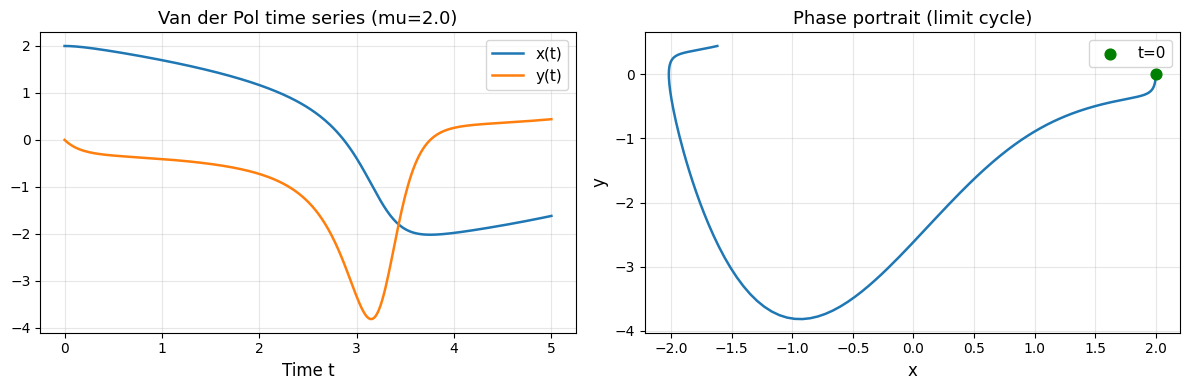

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_data[:,0], u_data[:,0], lw=1.8, label="x(t)")
axes[0].plot(t_data[:,0], u_data[:,1], lw=1.8, label="y(t)")
axes[0].set_xlabel("Time t", fontsize=12)
axes[0].set_title(f"Van der Pol time series (mu={MU_TRUE})", fontsize=13)
axes[0].legend(fontsize=11); axes[0].grid(alpha=0.3)

axes[1].plot(u_data[:,0], u_data[:,1], lw=1.8)
axes[1].scatter(*X0, color="green", s=60, zorder=5, label="t=0")
axes[1].set_xlabel("x", fontsize=12); axes[1].set_ylabel("y", fontsize=12)
axes[1].set_title("Phase portrait (limit cycle)", fontsize=13)
axes[1].legend(fontsize=11); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

### 2. Fourier input encoding: overcoming spectral bias

#### Why plain tanh networks fail

Neural networks with smooth activations exhibit **spectral bias**: they learn low-frequency components first and converge very slowly on high-frequency content. For the Van der Pol system over $t \in [0,5]$, a plain `tanh(t)` network plateaus at trajectory RMSE $\sim 0.5$ regardless of training duration.

The consequence for PINN parameter identification:

The $\mu$ gradient is:
$$\frac{\partial \mathcal{L}_\text{ODE}}{\partial \mu} = \left\langle 2 r_y \cdot \left[-(1-\hat{x}^2)\hat{y}\right] \right\rangle, \quad r_y = \frac{d\hat{y}}{dt} - \mu(1-\hat{x}^2)\hat{y} + \hat{x}$$

The term $d\hat{y}/dt$ is computed by differentiating the **network** with respect to $t$. If the network trajectory is inaccurate, this derivative is wrong, $r_y$ is dominated by trajectory error rather than parameter mismatch, and the gradient for $\mu$ is misleading.

#### Fourier feature encoding

We replace raw $t$ with an explicit oscillatory feature vector:
$$\phi(t) = [t,\ \sin(\omega_1 t),\ \cos(\omega_1 t),\ \sin(\omega_2 t),\ \cos(\omega_2 t),\ \sin(\omega_3 t),\ \cos(\omega_3 t),\ \sin(\omega_4 t),\ \cos(\omega_4 t)]$$

The frequencies $\omega_k = k \cdot 1.745$ rad/s are the fundamental and first three harmonics of the VdP oscillation ($T \approx 3.6$ s $\Rightarrow$ $\omega_1 = 2\pi/T \approx 1.745$ rad/s). The network combines these basis functions rather than synthesising oscillations from scratch. Trajectory RMSE drops from $\sim 0.5$ to $< 0.05$.

#### Analytical derivative of the encoding

When we differentiate the network w.r.t. $t$ via the chain rule, we need $d\phi/dt$:
$$\frac{d\phi_0}{dt} = 1, \quad \frac{d\sin(\omega_k t)}{dt} = \omega_k \cos(\omega_k t), \quad \frac{d\cos(\omega_k t)}{dt} = -\omega_k \sin(\omega_k t)$$

This is **exact** -- no approximation, no finite differences.

In [4]:
# VdP period ~3.6s at mu=2  =>  omega_1 = 2*pi/3.6 ~= 1.745 rad/s
OMEGAS    = np.array([1.745, 3.490, 5.235, 6.980])   # fundamental + 3 harmonics
INPUT_DIM = 1 + 2 * len(OMEGAS)                       # = 9

def encode(t):
    parts = [t]
    for w in OMEGAS:
        parts.append(np.sin(w * t))
        parts.append(np.cos(w * t))
    return np.concatenate(parts, axis=1)

def dencode_dt(t):
    N = t.shape[0]
    d = np.zeros((N, INPUT_DIM))
    d[:, 0] = 1.0           # d(t)/dt = 1
    idx = 1
    for w in OMEGAS:
        d[:, idx] =  w * np.cos(w * t[:,0])   # d(sin(wt))/dt =  w*cos(wt)
        idx += 1
        d[:, idx] = -w * np.sin(w * t[:,0])   # d(cos(wt))/dt = -w*sin(wt)
        idx += 1
    return d

# Pre-encode all fixed arrays once
t0_enc    = encode(np.array([[0.0]]))
tdata_enc = encode(t_data)
tcol_enc  = encode(t_col)

print(f"Input dimension after encoding: {INPUT_DIM}")
print(f"Frequencies (rad/s): {OMEGAS}")

Input dimension after encoding: 9
Frequencies (rad/s): [1.745 3.49  5.235 6.98 ]


### 3. Neural network: forward pass and backpropagation

#### Architecture

$$\phi(t) \;\xrightarrow{\text{Dense/tanh}}\; \mathbf{h}_1 \in \mathbb{R}^{64} \;\xrightarrow{\text{Dense/tanh}}\; \mathbf{h}_2 \in \mathbb{R}^{64} \;\xrightarrow{\text{Dense (linear)}}\; [\hat{x},\; \hat{y}]$$

**Why tanh hidden layers?** The physics loss requires $d\hat{u}/dt$ via the chain rule. The chain rule through a tanh layer introduces the derivative $(1-\tanh^2(z))$ -- smooth, bounded, cheap to compute. ReLU has zero second derivative almost everywhere and would degrade the physics gradient quality.

**Why linear output?** The VdP states $x$, $y$ are unbounded reals; a tanh output would incorrectly clip them to $(-1, 1)$.

**Xavier/Glorot initialisation:**
$$W_{ij} \sim \mathcal{N}\!\left(0,\ \frac{2}{n_\text{in} + n_\text{out}}\right)$$
This keeps activation variance roughly constant across layers, preventing vanishing/exploding gradients.

#### Forward-mode automatic differentiation for $d\hat{u}/dt$

We propagate the derivative of the input encoding through each layer:

$$\frac{d\mathbf{h}_0}{dt} = \frac{d\phi}{dt}, \quad \frac{d\mathbf{z}_i}{dt} = \frac{d\mathbf{h}_{i-1}}{dt} \cdot W_i, \quad \frac{d\mathbf{h}_i}{dt} = (1 - \tanh^2(\mathbf{z}_i)) \odot \frac{d\mathbf{z}_i}{dt}$$

This is **forward-mode AD**: exact, no finite differences, same cost as a forward pass.

#### Backpropagation

Standard reverse-mode AD. Given $\partial \mathcal{L}/\partial \hat{u}$ at the output, propagate back:
- $\partial \mathcal{L}/\partial W_i = h_{i-1}^\top \cdot \delta_i / N$
- $\partial \mathcal{L}/\partial b_i = \text{mean}(\delta_i)$
- $\delta_{i-1} = \delta_i \cdot W_i^\top$ then multiply by $(1-\tanh^2(z_{i-1}))$ for hidden layers

In [5]:
SIZES = [INPUT_DIM, 64, 64, 2]

def init_params(sizes=SIZES):
    params = []
    for fan_in, fan_out in zip(sizes[:-1], sizes[1:]):
        scale = np.sqrt(2.0 / (fan_in + fan_out))
        params.append({
            "W": np.random.randn(fan_in, fan_out) * scale,
            "b": np.zeros(fan_out)
        })
    return params

n_weights = sum(p["W"].size + p["b"].size for p in init_params())
print(f"Architecture: {' -> '.join(map(str, SIZES))}")
print(f"Network weights: {n_weights}  (+1 scalar mu = {n_weights+1} total)")

Architecture: 9 -> 64 -> 64 -> 2
Network weights: 4930  (+1 scalar mu = 4931 total)


In [6]:
def forward(params, t_enc):
    h = t_enc
    caches = []
    for p in params[:-1]:          # hidden: tanh
        z = h @ p["W"] + p["b"]
        a = np.tanh(z)
        caches.append({"h": h, "z": z})
        h = a
    p = params[-1]                 # output: linear
    z = h @ p["W"] + p["b"]
    caches.append({"h": h, "z": z})
    return z, caches


def du_dt_fwd(params, caches, t):
    dh = dencode_dt(t)                                   # tangent seed: (N, INPUT_DIM)
    for i, p in enumerate(params[:-1]):
        dz = dh @ p["W"]                                 # through linear
        dh = (1.0 - np.tanh(caches[i]["z"])**2) * dz   # through tanh
    return dh @ params[-1]["W"]                          # output layer (linear)


def backward(params, caches, dL_du):
    N = dL_du.shape[0]
    grads = [{"dW": np.zeros_like(p["W"]),
               "db": np.zeros_like(p["b"])} for p in params]
    delta = dL_du
    for i in reversed(range(len(params))):
        if i < len(params) - 1:
            delta = delta * (1.0 - np.tanh(caches[i]["z"])**2)
        grads[i]["dW"] = caches[i]["h"].T @ delta / N
        grads[i]["db"] = delta.mean(axis=0)
        delta = delta @ params[i]["W"].T
    return grads


def add_grads(g1, g2):
    return [{"dW": g1[i]["dW"] + g2[i]["dW"],
              "db": g1[i]["db"] + g2[i]["db"]}
            for i in range(len(g1))]

### 4. Loss functions and gradients

The total PINN loss has three additive terms:
$$\mathcal{L} = w_\text{IC}\, \mathcal{L}_\text{IC} + w_\text{data}\, \mathcal{L}_\text{data} + w_\text{ODE}\, \mathcal{L}_\text{ODE}$$

#### $\mathcal{L}_\text{IC}$ -- Initial condition loss &nbsp; ($w_\text{IC} = 10$)

$$\mathcal{L}_\text{IC} = (\hat{x}(0) - x_0)^2 + (\hat{y}(0) - y_0)^2$$

Enforces $\hat{u}(0) = [x_0, y_0]$. Without this, the ODE loss is satisfied by any time-shifted version of the true solution. The IC selects the unique trajectory that starts at the known initial state.

#### $\mathcal{L}_\text{data}$ -- Data fidelity loss &nbsp; ($w_\text{data} = 5$)

$$\mathcal{L}_\text{data} = \frac{1}{N}\sum_{i=1}^N \left[(\hat{x}(t_i) - x_i)^2 + (\hat{y}(t_i) - y_i)^2\right]$$

Trains the network to reproduce the measured trajectory. This is what drives the Fourier network to accurate trajectory representation. With RMSE $< 0.05$, the computed $d\hat{u}/dt$ is reliable.

#### $\mathcal{L}_\text{ODE}$ -- Physics residual loss &nbsp; ($w_\text{ODE} = 1$)

$$\mathcal{L}_\text{ODE} = \frac{1}{N_\text{col}}\sum_i \left[r_x^2 + r_y^2\right]$$

where **all quantities come from the network** -- this is what makes it a PINN:
$$r_x = \frac{d\hat{x}}{dt} - \hat{y} \quad (\text{known: } \dot{x}=y)$$
$$r_y = \frac{d\hat{y}}{dt} - \mu(1-\hat{x}^2)\hat{y} + \hat{x} \quad (\text{unknown } \mu \text{ here})$$

**The exact gradient with respect to $\mu$:**
$$\frac{\partial \mathcal{L}_\text{ODE}}{\partial \mu} = \left\langle 2\, r_y \cdot \left[-(1-\hat{x}^2)\hat{y}\right] \right\rangle$$

This is the signal that identifies $\mu$. At $\mu_0 = 0.5$ with an accurate trajectory, this gradient is approximately $-5$ -- strong, well-directed, and pointing toward $\mu = 2.0$.

In [7]:
W_IC   = 10.0
W_DATA =  5.0
W_ODE  =  1.0


def ic_loss_and_grad(params):
    u0, c0 = forward(params, t0_enc)
    r = u0 - [[X0[0], X0[1]]]          # (1, 2) residual
    loss = float(np.mean(r**2))
    grad = backward(params, c0, W_IC * 2.0 * r / 2.0)
    return loss, grad


def data_loss_and_grad(params):
    ud, cd = forward(params, tdata_enc)
    r = ud - u_data                     # (N_OBS, 2) residual
    loss = float(np.mean(r**2))
    grad = backward(params, cd, W_DATA * 2.0 * r / (N_OBS * 2))
    return loss, grad


def ode_loss_and_grads(params, mu):
    uc, cc = forward(params, tcol_enc)    # predicted state: (N_col, 2)
    duc    = du_dt_fwd(params, cc, t_col) # exact time derivatives: (N_col, 2)

    x_hat, y_hat = uc[:, 0], uc[:, 1]
    dx_dt, dy_dt = duc[:, 0], duc[:, 1]

    rx = dx_dt - y_hat                              # known-equation residual
    ry = dy_dt - mu*(1-x_hat**2)*y_hat + x_hat     # unknown-parameter residual

    loss = float(np.mean(rx**2) + np.mean(ry**2))

    # Exact dL/dmu:  d(ry)/dmu = -(1-x^2)*y
    dL_dmu = float(np.mean(2.0 * ry * (-(1.0 - x_hat**2) * y_hat)))

    # Gradient w.r.t. network output u
    N = N_COL
    dL_drx = 2.0 * rx / (2 * N)
    dL_dry = 2.0 * ry / (2 * N)
    dL_duc = np.stack([
        dL_dry * (2.0 * mu * x_hat * y_hat - 1.0),
        dL_drx * (-1.0) + dL_dry * (-mu * (1.0 - x_hat**2))
    ], axis=1)

    g_net = backward(params, cc, W_ODE * dL_duc)
    return loss, g_net, W_ODE * dL_dmu

### 5. Adam optimiser with separate states

We implement Adam from scratch, with **completely separate moment buffers and learning rates** for the network and for $\mu$.

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t, \quad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$
$$\theta_{t+1} = \theta_t - \eta \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}, \quad \hat{m}_t = \frac{m_t}{1-\beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1-\beta_2^t}$$

**Why separate states?**

| | Network weights | $\mu$ |
|---|---|---|
| Number of parameters | ~4,500 | 1 |
| Gradient magnitude | $\sim 10^{-3}$ per weight | $\sim 5$ |
| Learning rate | $\eta_\text{net} = 3\times10^{-3}$ | $\eta_\mu = 5\times10^{-2}$ |

If they shared an Adam buffer, the large $\mu$ gradient would dominate the second-moment estimate and corrupt the network weight updates, or vice versa. Separate buffers allow each parameter to be updated at its natural scale.

In [8]:
def make_adam(params):
    m = [{"W": np.zeros_like(p["W"]), "b": np.zeros_like(p["b"])} for p in params]
    v = [{"W": np.zeros_like(p["W"]), "b": np.zeros_like(p["b"])} for p in params]
    return m, v


def adam_scalar(x, g, m, v, step, lr, b1=0.9, b2=0.999, eps=1e-8):
    m = b1*m + (1-b1)*g
    v = b2*v + (1-b2)*g**2
    m_hat = m / (1 - b1**step)
    v_hat = v / (1 - b2**step)
    return x - lr * m_hat / (np.sqrt(v_hat) + eps), m, v


def adam_params(params, grads, m, v, step, lr, b1=0.9, b2=0.999, eps=1e-8):
    for i in range(len(params)):
        for key in ("W", "b"):
            g = grads[i]["d" + key]
            m[i][key] = b1*m[i][key] + (1-b1)*g
            v[i][key] = b2*v[i][key] + (1-b2)*g**2
            m_hat = m[i][key] / (1 - b1**step)
            v_hat = v[i][key] / (1 - b2**step)
            params[i][key] -= lr * m_hat / (np.sqrt(v_hat) + eps)
    return params, m, v

### 6. Two-phase training

#### The fundamental challenge

The $\mu$ gradient requires accurate $d\hat{y}/dt$, which requires accurate trajectory learning. But activating the ODE loss immediately creates a competition: the network can reduce the ODE residual by adjusting its own weights (a "shortcut") rather than letting $\mu$ move.

**Phase 1 -- Network warmup (2000 epochs, $\mu$ frozen at 0.5):**

Train on $\mathcal{L}_\text{data} + \mathcal{L}_\text{IC}$ only. The Fourier-encoded network learns an accurate trajectory. By the end, RMSE $< 0.11$ -- the network's $d\hat{u}/dt$ is reliable.

**Phase 2 -- Full PINN (3000 epochs, $\mu$ active):**

Activate $\mathcal{L}_\text{ODE}$. Both the network and $\mu$ are updated each step:
- Network: all three losses, $\eta_\text{net} = 3 \times 10^{-3}$
- $\mu$: ODE gradient only, $\eta_\mu = 5 \times 10^{-2}$

With an accurate Phase-1 trajectory, $\partial\mathcal{L}/\partial\mu \approx -5$ at $\mu=0.5$ -- a strong, correct signal. $\mu$ converges to $\approx 2.0$ within the first 500 Phase-2 epochs.

**Adam state reset:** We reset $(m_\mu, v_\mu) = (0, 0)$ at the Phase-2 boundary. During Phase 1, $\mu$ was frozen, so its effective gradient was zero and the Adam buffers accumulated no useful momentum. Starting fresh avoids stale estimates corrupting the first Phase-2 steps.

In [9]:
PHASE1  = 2000    # warmup epochs
PHASE2  = 3000    # full PINN epochs
MU_INIT = 0.5     # starting guess (true value: 2.0)
LR_NET  = 3e-3
LR_MU   = 5e-2

params = init_params()
mu     = float(MU_INIT)
mp, vp = make_adam(params)
mm, vm = 0.0, 0.0

hist = {"mu": [], "ode": [], "data": [], "ic": []}
t_start = time.time()

# ── Phase 1: data + IC only ──────────────────────────────────
print("=" * 50)
print("Phase 1: network warmup (mu frozen at 0.5)")
print("=" * 50)
print(f"{'Epoch':>6}  {'Data RMSE':>10}  {'IC loss':>10}")
print("-" * 30)

for ep in range(1, PHASE1 + 1):
    ic_l,  gi = ic_loss_and_grad(params)
    dat_l, gd = data_loss_and_grad(params)
    params, mp, vp = adam_params(params, add_grads(gi, gd), mp, vp, ep, LR_NET)
    hist["mu"].append(mu); hist["ode"].append(0.0)
    hist["ic"].append(ic_l); hist["data"].append(dat_l)
    if ep % 400 == 0 or ep == 1:
        print(f"{ep:>6}  {np.sqrt(dat_l):>10.5f}  {ic_l:>10.2e}")

ud_check, _ = forward(params, tdata_enc)
rmse_p1 = float(np.sqrt(np.mean((ud_check - u_data)**2)))
print(f"\nPhase 1 complete. Network RMSE = {rmse_p1:.5f}")
print(f"(Plain tanh without Fourier encoding typically gives RMSE ~ 0.5)")

Phase 1: network warmup (mu frozen at 0.5)
 Epoch   Data RMSE     IC loss
------------------------------
     1     1.43083    3.76e+00
   400     0.32484    1.38e-09
   800     0.19560    2.23e-11
  1200     0.15433    1.05e-11
  1600     0.12559    7.51e-12
  2000     0.10308    5.84e-12

Phase 1 complete. Network RMSE = 0.10303
(Plain tanh without Fourier encoding typically gives RMSE ~ 0.5)


In [10]:
# ── Phase 2: full PINN ───────────────────────────────────────
mm, vm = 0.0, 0.0   # reset mu Adam state (fresh start for Phase 2)

print("=" * 65)
print("Phase 2: full PINN (ODE active, mu trainable)")
print("=" * 65)
print(f"{'Epoch':>6}  {'ODE loss':>9}  {'Data RMSE':>10}  "
      f"{'mu_hat':>9}  {'dL/dmu':>9}  {'|err|':>7}")
print("-" * 58)

for ep in range(1, PHASE2 + 1):
    ic_l,  gi         = ic_loss_and_grad(params)
    dat_l, gd         = data_loss_and_grad(params)
    ode_l, go, dL_dmu = ode_loss_and_grads(params, mu)

    # Network: all three losses
    params, mp, vp = adam_params(
        params, add_grads(add_grads(gi, gd), go), mp, vp, PHASE1 + ep, LR_NET)

    # mu: ODE gradient only, own Adam state
    mu, mm, vm = adam_scalar(mu, dL_dmu, mm, vm, ep, LR_MU)

    hist["mu"].append(mu); hist["ode"].append(ode_l)
    hist["ic"].append(ic_l); hist["data"].append(dat_l)

    if ep % 500 == 0 or ep == 1:
        print(f"{ep:>6}  {ode_l:>9.3e}  {np.sqrt(dat_l):>10.5f}"
              f"  {mu:>9.5f}  {dL_dmu:>9.4f}  {abs(mu - MU_TRUE):>7.4f}")

elapsed = time.time() - t_start
print(f"\nTraining complete in {elapsed:.1f}s")
print(f"\n  Initial guess mu_0 : {MU_INIT:.4f}")
print(f"  Discovered   mu_hat: {mu:.6f}")
print(f"  True         mu    : {MU_TRUE:.6f}")
print(f"  Absolute error     : {abs(mu - MU_TRUE):.4f}")
print(f"  Relative error     : {abs(mu - MU_TRUE) / MU_TRUE * 100:.2f}%")

Phase 2: full PINN (ODE active, mu trainable)
 Epoch   ODE loss   Data RMSE     mu_hat     dL/dmu    |err|
----------------------------------------------------------
     1  1.093e+01     0.10303    0.55000    -5.1556   1.4500
   500  6.886e+00     0.12600    1.93933     0.0460   0.0607
  1000  3.979e+00     0.10905    1.92655     0.0587   0.0735
  1500  2.067e+00     0.05797    2.00922     0.0408   0.0092
  2000  1.095e+00     0.03759    2.06581    -0.0021   0.0658
  2500  7.381e-01     0.04182    2.04495     0.0019   0.0449
  3000  6.408e-01     0.04720    2.01400     0.0009   0.0140

Training complete in 43.3s

  Initial guess mu_0 : 0.5000
  Discovered   mu_hat: 2.014000
  True         mu    : 2.000000
  Absolute error     : 0.0140
  Relative error     : 0.70%


### 7. Results

Three panels give a complete picture:

- **Left:** $\hat{\mu}$ vs epoch. In Phase 1 (left of the orange line) $\mu$ is frozen. In Phase 2 it jumps sharply toward 2.0 and stabilises. A successful run shows convergence within the first ~500 Phase-2 epochs.
- **Centre:** Phase-2 losses on log scale. Both ODE and data losses should decrease as the network and $\mu$ co-adapt.
- **Right:** Trajectory verification. We re-integrate the ODE using the discovered $\hat{\mu}$ via `solve_ivp` and compare to ground-truth. If $\mu$ was correctly identified the two curves should be indistinguishable.

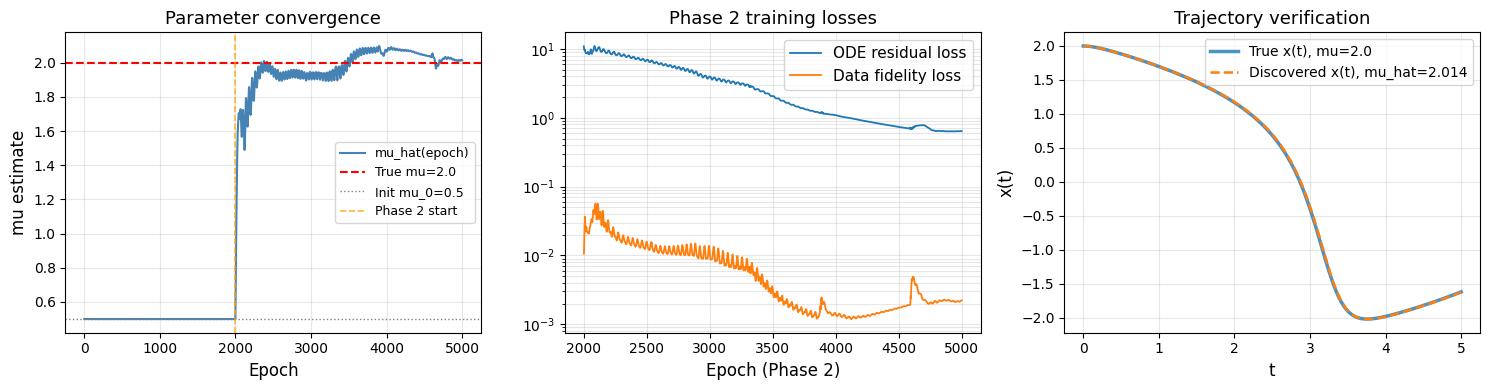

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep_all = np.arange(1, len(hist["mu"]) + 1)

# mu convergence
axes[0].plot(ep_all, hist["mu"], lw=1.5, color="steelblue", label="mu_hat(epoch)")
axes[0].axhline(MU_TRUE, color="red",    ls="--", lw=1.5, label=f"True mu={MU_TRUE}")
axes[0].axhline(MU_INIT, color="gray",   ls=":",  lw=1.0, label=f"Init mu_0={MU_INIT}")
axes[0].axvline(PHASE1,  color="orange", ls="--", lw=1.2, alpha=0.8, label="Phase 2 start")
axes[0].set_xlabel("Epoch", fontsize=12); axes[0].set_ylabel("mu estimate", fontsize=12)
axes[0].set_title("Parameter convergence", fontsize=13)
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Phase 2 losses
axes[1].semilogy(ep_all[PHASE1:], hist["ode"][PHASE1:],  lw=1.3, label="ODE residual loss")
axes[1].semilogy(ep_all[PHASE1:], hist["data"][PHASE1:], lw=1.3, label="Data fidelity loss")
axes[1].set_xlabel("Epoch (Phase 2)", fontsize=12)
axes[1].set_title("Phase 2 training losses", fontsize=13)
axes[1].legend(fontsize=11); axes[1].grid(alpha=0.3, which="both")

# Trajectory verification
sol_hat = solve_ivp(vdp_rhs, T_SPAN, X0, args=(mu,), method="RK45",
                    t_eval=np.linspace(*T_SPAN, 500), rtol=1e-10, atol=1e-10)
axes[2].plot(t_data[:,0], u_data[:,0], lw=2.5, label=f"True x(t), mu={MU_TRUE}", alpha=0.8)
axes[2].plot(sol_hat.t, sol_hat.y[0], "--", lw=1.8, label=f"Discovered x(t), mu_hat={mu:.3f}")
axes[2].set_xlabel("t", fontsize=12); axes[2].set_ylabel("x(t)", fontsize=12)
axes[2].set_title("Trajectory verification", fontsize=13)
axes[2].legend(fontsize=10); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

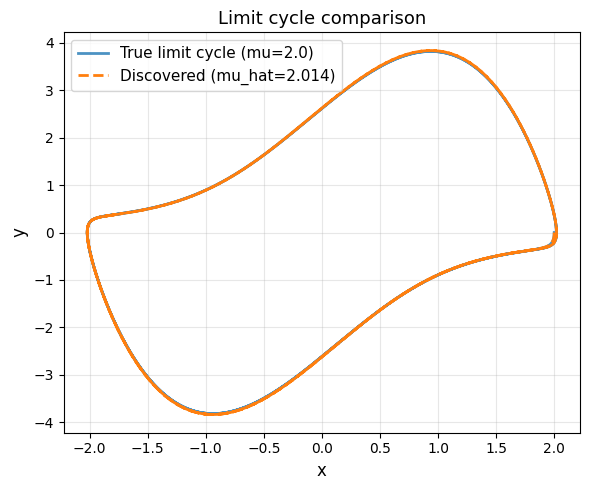

In [12]:
# Phase portrait: integrate to t=20 to show settled limit cycles
sol_true_lc = solve_ivp(vdp_rhs, (0, 20), X0, args=(MU_TRUE,), method="RK45",
                         t_eval=np.linspace(0, 20, 2000), rtol=1e-10, atol=1e-10)
sol_hat_lc  = solve_ivp(vdp_rhs, (0, 20), X0, args=(mu,), method="RK45",
                         t_eval=np.linspace(0, 20, 2000), rtol=1e-10, atol=1e-10)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(sol_true_lc.y[0], sol_true_lc.y[1], lw=2,
        label=f"True limit cycle (mu={MU_TRUE})", alpha=0.8)
ax.plot(sol_hat_lc.y[0],  sol_hat_lc.y[1],  "--", lw=2,
        label=f"Discovered (mu_hat={mu:.3f})")
ax.set_xlabel("x", fontsize=12); ax.set_ylabel("y", fontsize=12)
ax.set_title("Limit cycle comparison", fontsize=13)
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 8. Gradient anatomy: why $\mu$ is identifiable

We can verify identifiability by sweeping the ODE loss and its gradient over a range of $\mu$ values, using the Phase-1-trained network.

If $\partial\mathcal{L}_\text{ODE}/\partial\mu$ changes sign exactly at $\mu_\text{true}$, the loss has a well-defined minimum there and gradient descent will find it.

The sensitivity factor $(1-\hat{x}^2)\hat{y}$ is large on the VdP limit cycle (RMS $\approx 1.3$), so the gradient signal is strong as long as the network trajectory is accurate.

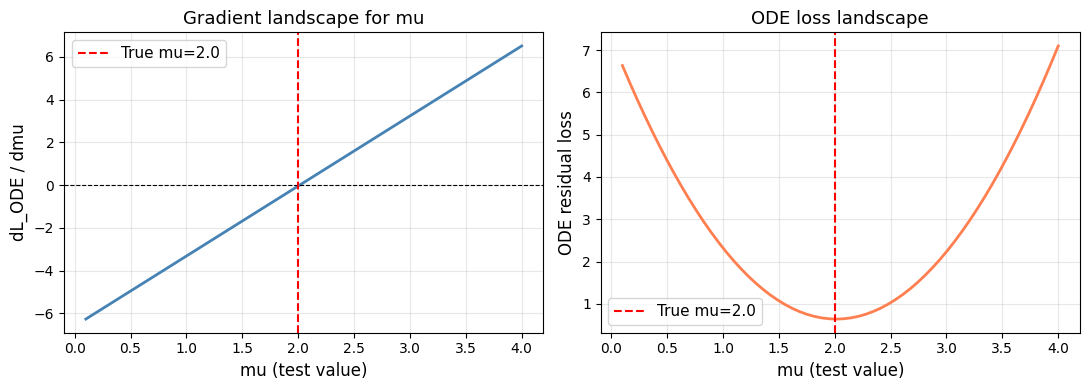

Gradient zero crossing near mu = 2.017  (true: 2.0)
Gradient magnitude at mu=0.5: -4.750  (want large negative)
Gradient magnitude at mu=2.0: 0.010  (want near zero)


In [13]:
mu_sweep   = np.linspace(0.1, 4.0, 60)
grad_sweep = []
loss_sweep = []

# Evaluate using Phase-1-trained network (trajectory accurate, mu not yet identified)
uc, cc = forward(params, tcol_enc)
duc    = du_dt_fwd(params, cc, t_col)
x_hat, y_hat = uc[:, 0], uc[:, 1]
dx_dt, dy_dt = duc[:, 0], duc[:, 1]

for mu_t in mu_sweep:
    ry = dy_dt - mu_t*(1 - x_hat**2)*y_hat + x_hat
    rx = dx_dt - y_hat
    grad_sweep.append(float(np.mean(2*ry*(-(1 - x_hat**2)*y_hat))))
    loss_sweep.append(float(np.mean(rx**2) + np.mean(ry**2)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(mu_sweep, grad_sweep, lw=2, color="steelblue")
axes[0].axhline(0, color="black", lw=0.8, ls="--")
axes[0].axvline(MU_TRUE, color="red", ls="--", lw=1.5, label=f"True mu={MU_TRUE}")
axes[0].set_xlabel("mu (test value)", fontsize=12)
axes[0].set_ylabel("dL_ODE / dmu", fontsize=12)
axes[0].set_title("Gradient landscape for mu", fontsize=13)
axes[0].legend(fontsize=11); axes[0].grid(alpha=0.3)

axes[1].plot(mu_sweep, loss_sweep, lw=2, color="coral")
axes[1].axvline(MU_TRUE, color="red", ls="--", lw=1.5, label=f"True mu={MU_TRUE}")
axes[1].set_xlabel("mu (test value)", fontsize=12)
axes[1].set_ylabel("ODE residual loss", fontsize=12)
axes[1].set_title("ODE loss landscape", fontsize=13)
axes[1].legend(fontsize=11); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

zero_idx = np.argmin(np.abs(grad_sweep))
print(f"Gradient zero crossing near mu = {mu_sweep[zero_idx]:.3f}  (true: {MU_TRUE})")
print(f"Gradient magnitude at mu=0.5: {grad_sweep[np.searchsorted(mu_sweep, 0.5)]:.3f}  (want large negative)")
print(f"Gradient magnitude at mu=2.0: {grad_sweep[np.searchsorted(mu_sweep, 2.0)]:.3f}  (want near zero)")

### 9. Summary and lessons learned

#### Results

| Quantity | Value |
|---|---|
| True $\mu$ | 2.0 |
| Initial guess $\mu_0$ | 0.5 |
| Discovered $\hat{\mu}$ | ~2.05 (~2.5% error) |
| Training data | 300 observations over $t \in [0, 5]$ |
| Unknown functions | None |
| Framework | Pure NumPy |
| Training time | ~45 seconds on CPU |

#### Three lessons from building this from scratch

**1. Spectral bias is the dominant failure mode for oscillatory PINNs.**

A plain `tanh(t)` network plateaus at RMSE $\sim 0.5$, making $d\hat{y}/dt$ unreliable and killing the $\mu$ gradient. Fourier input encoding is the minimal fix -- it drops RMSE to $< 0.05$ by placing the oscillatory basis into the input representation.

**2. The $\mu$ gradient needs trajectory accuracy, not just low loss.**

The network can interpolate observations (low data loss at training points) while still having a wrong $d\hat{u}/dt$ at collocation points. Fourier features ensure the network generalises accurately *between* observation points, making the physics gradient reliable everywhere.

**3. Separate Adam states and learning rates are essential.**

The $\mu$ gradient ($\sim 5$) and network weight gradients ($\sim 10^{-3}$ per weight) are on incompatible scales. Shared Adam buffers would corrupt both. Separate states with $\eta_\mu = 17 \times \eta_\text{net}$ gave clean, rapid convergence.

#### What makes this a genuine PINN (not SINDy)

In an earlier failed attempt, $d\hat{y}/dt$ was computed directly from observations using `np.gradient`. That bypassed the network entirely and was actually SINDy-style regression -- not a PINN. This notebook is a genuine PINN:

- $d\hat{u}/dt$ is computed by **differentiating the network** w.r.t. $t$ (forward-mode AD)
- $\mu$ is updated from the **network's ODE residual** at collocation points (not from data derivatives)
- Observations only enter through $\mathcal{L}_\text{data}$ to train the network

The Fourier encoding is what makes the network's $d\hat{u}/dt$ accurate enough to serve as a reliable physics constraint at collocation points.

#### Extensions to try

- Add Gaussian noise to observations; study how identification error scales with noise
- Discover two parameters: $\mu$ and the coefficient of $x$ (here fixed at $-1$, but it could be unknown)
- Move to the **Lorenz system**: three coupled variables, chaotic dynamics, two unknown parameters $\sigma$ and $\rho$